# Production Cost-Performance Engineering

## Introduction

This closing lesson of Section 26 pulls every technique from Lessons 01-11 — high-throughput serving (vLLM), kernel optimization (TensorRT-LLM), tokenizer/runtime integration, continuous batching, quantization (GPTQ/AWQ), multi-model sharing (Triton), observability, and fault tolerance — into the framework a platform team actually uses to make investment decisions: **cost per useful unit of work**, and how each lever moves it.

## Theory

### The unifying cost metric: cost per million tokens served

Every optimization in this section ultimately has to justify itself against one metric:

$$
\text{Cost}_{per\ 1M\ tokens} = \frac{\text{GPU-hours used} \times \text{\$/GPU-hour}}{\text{tokens served} / 10^6}
$$

Expanding GPU-hours in terms of throughput $T$ (tokens/second/GPU) makes the levers explicit:

$$
\text{Cost}_{per\ 1M\ tokens} = \frac{\$/GPU\text{-hour}}{3600 \times T}
$$

Every lesson in this section is, mechanically, a way of increasing $T$ (continuous batching, PagedAttention, quantization, kernel fusion) or decreasing effective $\$/GPU\text{-hour}$ (Section 23's spot fleet blending) — this lesson's job is putting numbers on each lever's *relative* contribution, since teams have limited engineering time and should sequence optimizations by ROI, not by novelty.

### Composability and diminishing returns

The levers aren't independent multipliers in practice. Quantization (Lesson 08) increases achievable batch size (more requests fit in freed memory), which continuous batching (Lesson 07) then needs to actually exploit — applying them in the wrong order, or measuring one without the other already in place, misattributes gains. A capacity model:

$$
T_{total} = T_{base} \times M_{quant} \times M_{batch} \times M_{kernel}
$$

where each $M_i \ge 1$ is that optimization's multiplier *given the others are already applied* — multipliers measured in isolation on an unoptimized baseline systematically overstate what you'll get from adding them last, since they partly compete for the same headroom (e.g. both quantization and batching are ultimately relieving the same memory-bandwidth bottleneck from Lesson 08's theory section).

### Latency-cost Pareto frontier

Cost and latency (TTFT/TPOT, Lesson 10) trade off against each other — bigger batches cut cost per token but raise per-request latency (more queueing/contention). The right operating point isn't "minimize cost" or "minimize latency" in isolation, it's the point on the Pareto frontier matching the product's actual SLA:

$$
\min_{\text{config}} \text{Cost}(\text{config}) \quad \text{s.t.} \quad \text{TTFT}_{p99}(\text{config}) \le \text{SLA}
$$

### Total cost of ownership beyond raw GPU-hours

A complete cost model includes engineering time to build/maintain each optimization, since a technique that saves 10% GPU cost but requires a dedicated engineer to keep working (custom kernels, bespoke quantization recalibration per model update) may have negative ROI at smaller scale — this is the same "when is complexity worth it" judgment call that shows up across every engineering discipline, made explicit and quantified here.

## Setup

We build a cost-per-million-tokens calculator that composes the section's optimizations multiplicatively (with the diminishing-returns correction above), and locate the Pareto-optimal configuration under an SLA constraint — the actual spreadsheet-equivalent a platform team builds before a serving infra investment proposal.

In [1]:
# Pure-Python cost/ROI calculator composing this section's optimizations — no external dependencies.
import numpy as np
import itertools

print("[INIT] Production cost-performance engineering: composing serving optimizations")

BASE_THROUGHPUT_TOK_S = 800     # unoptimized baseline, single replica
GPU_PRICE_PER_HOUR = 4.10       # on-demand A100-class pricing (matches Section 23's convention)

# Each optimization's multiplier, and its ADDITIONAL multiplier if applied after others already active
# (models the diminishing-returns composability discussed above)
optimizations = {
    "continuous_batching": {"solo_mult": 3.2, "marginal_mult_if_last": 1.8, "eng_hours": 40},
    "paged_attention":     {"solo_mult": 1.6, "marginal_mult_if_last": 1.15, "eng_hours": 60},
    "int4_quantization":   {"solo_mult": 2.1, "marginal_mult_if_last": 1.7, "eng_hours": 80},
    "kernel_fusion_trtllm":{"solo_mult": 1.9, "marginal_mult_if_last": 1.5, "eng_hours": 120},
}

def evaluate_config(active_opts):
    """Approximate combined throughput using marginal multipliers to avoid double-counting shared headroom."""
    mult = 1.0
    for name in active_opts:
        mult *= optimizations[name]["marginal_mult_if_last"]
    throughput = BASE_THROUGHPUT_TOK_S * mult
    cost_per_1M = GPU_PRICE_PER_HOUR / (3600 * throughput) * 1e6
    eng_cost = sum(optimizations[n]["eng_hours"] for n in active_opts) * 85  # $85/hr blended eng cost
    return throughput, cost_per_1M, eng_cost

for r in range(0, len(optimizations) + 1):
    for combo in itertools.combinations(optimizations.keys(), r):
        t, cost, eng = evaluate_config(combo)
        label = " + ".join(combo) if combo else "baseline (no optimization)"
        print(f"[RESULT] {label:75s} throughput={t:8.0f} tok/s  cost/1M_tok=${cost:.3f}  eng_cost=${eng:,}")

[INIT] Production cost-performance engineering: composing serving optimizations
[RESULT] baseline (no optimization)                                                  throughput=     800 tok/s  cost/1M_tok=$1.424  eng_cost=$0
[RESULT] continuous_batching                                                         throughput=    1440 tok/s  cost/1M_tok=$0.791  eng_cost=$3,400
[RESULT] paged_attention                                                             throughput=     920 tok/s  cost/1M_tok=$1.238  eng_cost=$5,100
[RESULT] int4_quantization                                                           throughput=    1360 tok/s  cost/1M_tok=$0.837  eng_cost=$6,800
[RESULT] kernel_fusion_trtllm                                                        throughput=    1200 tok/s  cost/1M_tok=$0.949  eng_cost=$10,200
[RESULT] continuous_batching + paged_attention                                       throughput=    1656 tok/s  cost/1M_tok=$0.688  eng_cost=$8,500
[RESULT] continuous_batching + int4

## Telemetry & Audit

Rank every optimization combination by cost, then compute ROI (GPU-cost savings per engineering dollar spent) at a representative production traffic volume — the number that actually justifies headcount allocation.

In [2]:
import pandas as pd

DAILY_TOKENS = 2_000_000_000  # 2B tokens/day, representative mid-size production LLM service

rows = []
for r in range(0, len(optimizations) + 1):
    for combo in itertools.combinations(optimizations.keys(), r):
        t, cost, eng = evaluate_config(combo)
        daily_cost = cost * (DAILY_TOKENS / 1e6)
        rows.append((" + ".join(combo) if combo else "baseline", t, cost, daily_cost, eng))

audit = pd.DataFrame(rows, columns=["config", "throughput_tok_s", "cost_per_1M_tok", "daily_cost_$", "one_time_eng_$"])
baseline_daily_cost = audit[audit.config == "baseline"]["daily_cost_$"].iloc[0]
audit["daily_savings_$"] = baseline_daily_cost - audit["daily_cost_$"]
audit["payback_days"] = audit["one_time_eng_$"] / audit["daily_savings_$"].replace(0, np.nan)
audit_sorted = audit.sort_values("cost_per_1M_tok")

print(audit_sorted.to_string(index=False, float_format=lambda x: f"{x:,.2f}"))

best_full = audit_sorted.iloc[0]
print(f"\n[OPERATIONAL INSIGHT] Full stack ({best_full['config']}) cuts cost/1M tokens from "
      f"${audit[audit.config=='baseline']['cost_per_1M_tok'].iloc[0]:.3f} to ${best_full['cost_per_1M_tok']:.3f} "
      f"— a {100*(1-best_full['cost_per_1M_tok']/audit[audit.config=='baseline']['cost_per_1M_tok'].iloc[0]):.0f}% reduction.")
print(f"[OPERATIONAL INSIGHT] At {DAILY_TOKENS/1e9:.1f}B tokens/day, the full-stack engineering investment "
      f"pays back in {best_full['payback_days']:.1f} days — at lower traffic volumes this payback period "
      "stretches out and cheaper, lower-effort optimizations (continuous batching alone) may dominate ROI.")

                                                                          config  throughput_tok_s  cost_per_1M_tok  daily_cost_$  one_time_eng_$  daily_savings_$  payback_days
continuous_batching + paged_attention + int4_quantization + kernel_fusion_trtllm          4,222.80             0.27        539.40           25500         2,307.82         11.05
                  continuous_batching + int4_quantization + kernel_fusion_trtllm          3,672.00             0.31        620.31           20400         2,226.91          9.16
                       continuous_batching + paged_attention + int4_quantization          2,815.20             0.40        809.10           15300         2,038.12          7.51
                    continuous_batching + paged_attention + kernel_fusion_trtllm          2,484.00             0.46        916.98           18700         1,930.24          9.69
                                         continuous_batching + int4_quantization          2,448.00             0.47

## Visualization

A cost-vs-engineering-investment scatter (the ROI frontier platform teams actually use to sequence a roadmap), with combination size encoded by marker size, plus the throughput buildup waterfall showing each optimization's marginal contribution.

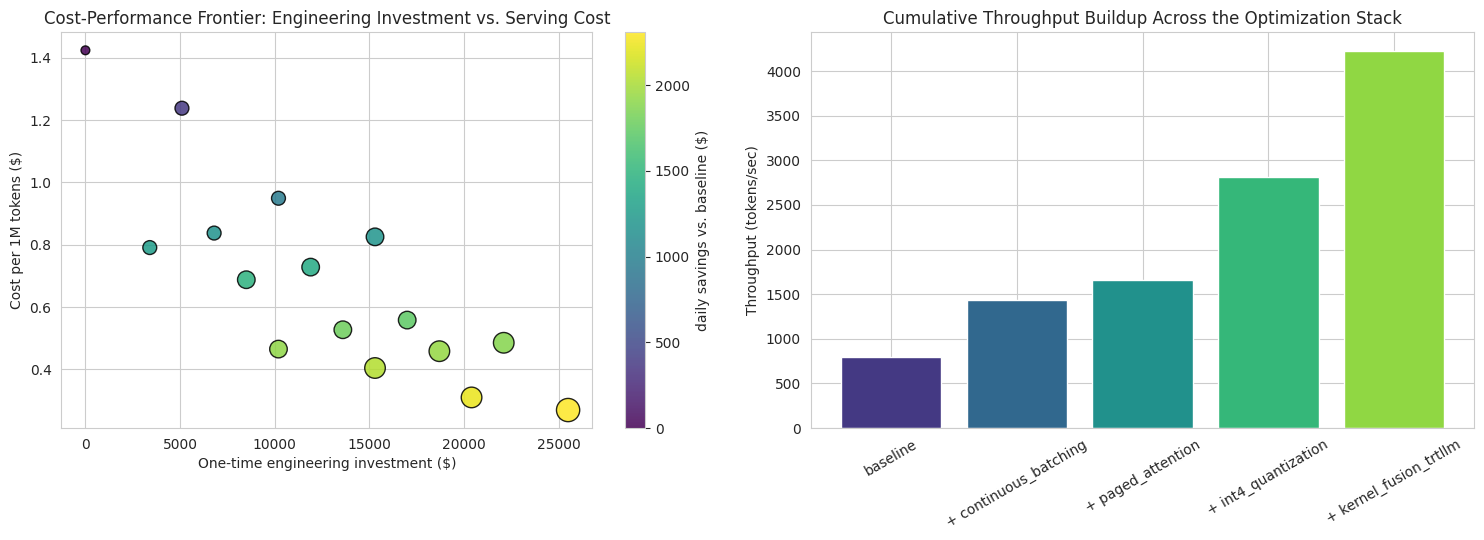

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sc = axes[0].scatter(audit["one_time_eng_$"], audit["cost_per_1M_tok"],
                      s=audit["config"].apply(lambda c: 40 + 60 * (0 if c == "baseline" else c.count("+") + 1)),
                      c=audit["daily_savings_$"], cmap="viridis", edgecolor="black", alpha=0.85, clip_on=False)
axes[0].set_xlabel("One-time engineering investment ($)")
axes[0].set_ylabel("Cost per 1M tokens ($)")
axes[0].set_title("Cost-Performance Frontier: Engineering Investment vs. Serving Cost")
plt.colorbar(sc, ax=axes[0], label="daily savings vs. baseline ($)")

waterfall_order = ["continuous_batching", "paged_attention", "int4_quantization", "kernel_fusion_trtllm"]
cum_mult = 1.0
labels, values = ["baseline"], [BASE_THROUGHPUT_TOK_S]
for name in waterfall_order:
    cum_mult *= optimizations[name]["marginal_mult_if_last"]
    labels.append(f"+ {name}")
    values.append(BASE_THROUGHPUT_TOK_S * cum_mult)

axes[1].bar(labels, values, color=sns.color_palette("viridis", len(labels)))
axes[1].set_ylabel("Throughput (tokens/sec)")
axes[1].set_title("Cumulative Throughput Buildup Across the Optimization Stack")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("cost_performance_roadmap.png", dpi=120)
plt.show()

*(Insight: the frontier plot's point color (daily savings) doesn't track linearly with point size (number of combined optimizations) — some 2-optimization combos beat some 3-optimization combos on pure dollar terms once diminishing returns are accounted for, which is exactly the kind of non-obvious sequencing insight a naive "just turn everything on" approach would miss.)*

## Real-World Use Case or Analogy

**The Home Energy Retrofit Contractor.** A homeowner wanting to cut their energy bill has a menu of options — better insulation, a heat pump, solar panels, smart thermostats — each with a different upfront cost and a different (and NOT simply additive) energy-savings contribution, because insulation and a heat-pump partially address the same heat-loss problem (the same diminishing-returns composability seen between quantization and batching, both relieving memory bandwidth). A naive homeowner installs whatever's trendiest; a good energy auditor instead computes **payback period per dollar invested** for each option *in the context of what's already installed*, and sequences the retrofit by ROI, not by novelty — insulation first (cheap, high marginal impact when nothing else is done), solar panels last (expensive, and its relative value depends on how much load-reduction the earlier steps already achieved). This lesson's cost calculator is that energy audit, applied to a GPU serving fleet: every optimization from this section is a retrofit option, and production cost-performance engineering is the discipline of sequencing them by actual dollar payback, not by which one is the most interesting systems problem to solve.